## Figure 2 - Behavioral performance across experience

This script generates Figure 2, showing behavior metrics
across experience levels (Familiar, Novel, Novel+) including d-prime, hit rate,
response latency, running speed, pupil width, and lick rate.

In [66]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import seaborn as sns

sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 2})

import visual_behavior.utilities as vbu
import visual_behavior.data_access.utilities as utilities
from visual_behavior.data_access import loading as loading

import visual_behavior.visualization.utils as utils
import visual_behavior.visualization.ophys.platform_paper_figures as ppf

from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [67]:
save_dir = os.path.join(loading.get_figures_save_dir(), 'platform_paper_figures', 'figure_2')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

palette = utils.get_experience_level_colors()
experience_levels = utils.get_new_experience_levels()
cell_types = utils.get_cell_types()

## Data Loading

### Metadata tables

In [68]:
# AllenSDK cache
platform_cache_dir = loading.get_platform_analysis_cache_dir()
cache = loading._get_cache()

# Curated metadata tables
metadata_tables_dir = loading.get_metadata_tables_dir()
experiments_table = pd.read_csv(os.path.join(metadata_tables_dir, 'all_ophys_experiments_table.csv'), index_col=0)
platform_experiments = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_experiments_table.csv'), index_col=0)
platform_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_cells_table.csv'), index_col=0)
platform_behavior_sessions = pd.read_csv(os.path.join(loading.get_platform_analysis_cache_dir(), 'platform_behavior_sessions_table.csv'), index_col=0)
platform_ophys_behavior_sessions = pd.read_csv(os.path.join(loading.get_platform_analysis_cache_dir(), 'platform_ophys_behavior_sessions_table.csv'), index_col=0)

# save to more convenient name
behavior_sessions = platform_behavior_sessions.copy()

# Cre lines, cell types, and palette for plotting
cre_lines = np.sort(platform_cells_table.cre_line.unique())
palette = utils.get_experience_level_colors()
cell_types = utils.get_cell_types()

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

In [69]:
print(len(behavior_sessions.mouse_id.unique()), 'mice')
print(len(behavior_sessions.index.unique()), 'behavior sessions')


66 mice
2942 behavior sessions


In [70]:
print(len(platform_ophys_behavior_sessions.mouse_id.unique()), 'mice')
print(len(platform_ophys_behavior_sessions.ophys_experiment_id.unique()), 'experiments')
print(len(platform_ophys_behavior_sessions.ophys_session_id.unique()), 'ophys sessions')
print(len(platform_ophys_behavior_sessions.index.unique()), 'behavior sessions')


66 mice
202 experiments
202 ophys sessions
202 behavior sessions


### Multi-session dataframes for behavior variables

In [71]:
# # Set params
# interpolate = False
# output_sampling_rate = 30
# inclusion_criteria = 'platform_experiment_table'

# # Running speed
# event_type = 'all'
# data_type = 'running_speed'
# conditions = ['ophys_experiment_id', 'is_change']
# running_speed_mdf = loading.get_multi_session_df_for_conditions(data_type, event_type, conditions, inclusion_criteria,
#                                                                interpolate=interpolate, output_sampling_rate=output_sampling_rate,
#                                                                epoch_duration_mins=None)
# running_speed_mdf_changes = running_speed_mdf[running_speed_mdf.is_change == True]
# running_speed_mdf_changes = running_speed_mdf_changes.drop_duplicates(subset='behavior_session_id')

# # Running speed - epochs
# conditions_epochs = ['ophys_experiment_id', 'is_change', 'epoch']
# running_speed_mdf_epochs = loading.get_multi_session_df_for_conditions(data_type, 'all', conditions_epochs, inclusion_criteria,
#                                                                        interpolate=interpolate, output_sampling_rate=output_sampling_rate,
#                                                                        epoch_duration_mins=5)
# running_speed_mdf_changes_epochs = running_speed_mdf_epochs[running_speed_mdf_epochs.is_change == True]
# running_speed_mdf_images_epochs = running_speed_mdf_epochs[running_speed_mdf_epochs.is_change == False]

# # Pupil width
# data_type = 'pupil_width'
# conditions = ['ophys_experiment_id', 'is_change']
# full_pupil_mdf = loading.get_multi_session_df_for_conditions(data_type, 'all', conditions, inclusion_criteria,
#                                                             interpolate=interpolate, output_sampling_rate=output_sampling_rate,
#                                                             epoch_duration_mins=None)
# pupil_mdf = full_pupil_mdf[full_pupil_mdf.is_change == True]
# pupil_mdf = pupil_mdf.drop_duplicates(subset='behavior_session_id')
# pupil_mdf = pupil_mdf[pupil_mdf.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]

# # Pupil width - epochs
# conditions_epochs = ['ophys_experiment_id', 'is_change', 'epoch']
# pupil_mdf_epochs = loading.get_multi_session_df_for_conditions(data_type, 'all', conditions_epochs, inclusion_criteria,
#                                                               interpolate=interpolate, output_sampling_rate=output_sampling_rate,
#                                                               epoch_duration_mins=5)
# pupil_mdf_changes_epochs = pupil_mdf_epochs[pupil_mdf_epochs.is_change == True]

# # Lick rate
# data_type = 'lick_rate'
# conditions = ['ophys_experiment_id', 'is_change']
# lick_rate_mdf = loading.get_multi_session_df_for_conditions(data_type, 'all', conditions, inclusion_criteria,
#                                                            interpolate=interpolate, output_sampling_rate=output_sampling_rate,
#                                                            epoch_duration_mins=None)
# lick_rate_mdf = lick_rate_mdf[lick_rate_mdf.is_change == True]
# lick_rate_mdf = lick_rate_mdf.drop_duplicates(subset='behavior_session_id')
# lick_rate_mdf = lick_rate_mdf[lick_rate_mdf.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]

# # Lick rate - epochs
# conditions_epochs = ['ophys_experiment_id', 'is_change', 'epoch']
# lick_rate_mdf_epochs = loading.get_multi_session_df_for_conditions(data_type, 'all', conditions_epochs, inclusion_criteria,
#                                                                   interpolate=interpolate, output_sampling_rate=output_sampling_rate,
#                                                                   epoch_duration_mins=5)
# lick_rate_mdf_changes_epochs = lick_rate_mdf_epochs[lick_rate_mdf_epochs.is_change == True]
# lick_rate_mdf_images_epochs = lick_rate_mdf_epochs[lick_rate_mdf_epochs.is_change == False]

### Behavior metrics

In [72]:
behavior_metrics_dir = loading.get_performance_metrics_dir()

# Behavior metrics computed by AllenSDK
behavior_stats_sdk = pd.read_hdf(os.path.join(behavior_metrics_dir, 'sdk_all_sessions.h5'), key='data')
behavior_stats_sdk.index.name = 'behavior_session_id'
columns = ['mouse_id', 'cre_line', 'cell_type', 'experience_level', 'session_type', 'behavior_session_id']
behavior_stats_sdk = behavior_stats_sdk.merge(behavior_sessions.reset_index()[columns], on='behavior_session_id', how='left')
# Limit to platform paper mice - behavior sessions with ophys
behavior_stats_sdk = behavior_stats_sdk[behavior_stats_sdk.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]
behavior_stats_sdk['mouse_id'] = [int(mouse_id) for mouse_id in behavior_stats_sdk.mouse_id.values]

# Behavior metrics computed on a flash by flash basis, limited to engaged portions of session
engaged_behavior_stats_stim = pd.read_hdf(os.path.join(loading.get_platform_analysis_cache_dir(), 'stimulus_based_engaged_only_all_sessions.h5'), key='data')
engaged_behavior_stats_stim = engaged_behavior_stats_stim.merge(behavior_sessions, on='behavior_session_id', how='left')
# Limit to platform paper mice - behavior sessions with ophys
engaged_behavior_stats_stim = engaged_behavior_stats_stim[engaged_behavior_stats_stim.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]


# Behavior metrics computed on a flash by flash basis, limited to engaged portions of session
behavior_stats_stim = pd.read_hdf(os.path.join(behavior_metrics_dir, 'stimulus_based_all_sessions.h5'), key='data')
behavior_stats_stim = behavior_stats_stim.merge(behavior_sessions, on='behavior_session_id', how='left')
# Limit to platform paper mice - behavior sessions with ophys
behavior_stats_stim = behavior_stats_stim[behavior_stats_stim.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]


# Load platform behavior stats for stimulus-based metrics
platform_behavior_stats = pd.read_csv(os.path.join(behavior_metrics_dir,  'platform_behavior_stats_engaged.csv'), index_col=0)
platform_behavior_stats = platform_behavior_stats.merge(behavior_sessions, on='behavior_session_id', how='left')
# Limit to platform paper mice - behavior sessions with ophys
platform_behavior_stats = platform_behavior_stats[platform_behavior_stats.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]


In [73]:
print(len(behavior_stats_sdk.mouse_id.unique()), 'mice')
print(len(behavior_stats_sdk.index.unique()), 'behavior sessions')


66 mice
202 behavior sessions


In [74]:
print(len(engaged_behavior_stats_stim.mouse_id.unique()), 'mice')
print(len(engaged_behavior_stats_stim.ophys_experiment_id.unique()), 'experiments')
print(len(engaged_behavior_stats_stim.ophys_session_id.unique()), 'ophys sessions')
print(len(engaged_behavior_stats_stim.index.unique()), 'behavior sessions')


66 mice
202 experiments
202 ophys sessions
202 behavior sessions


In [75]:
print(len(behavior_stats_stim.mouse_id.unique()), 'mice')
print(len(behavior_stats_stim.ophys_experiment_id.unique()), 'experiments')
print(len(behavior_stats_stim.ophys_session_id.unique()), 'ophys sessions')
print(len(behavior_stats_stim.index.unique()), 'behavior sessions')


66 mice
202 experiments
202 ophys sessions
202 behavior sessions


## Plotting

### Panel A: Lick raster for Familiar/Novel/Novel+ comparison
Select example mouse with data at all experience levels

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

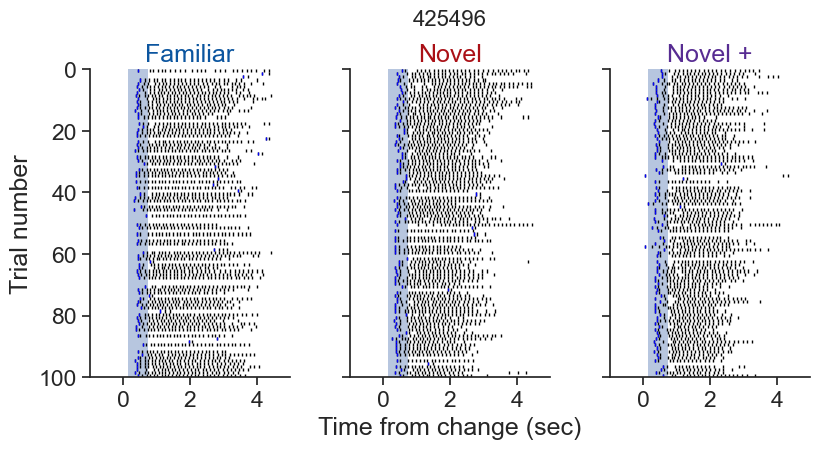

In [76]:
mouse_id = 425496

# Get datasets for each experience level
familiar_experiment_id = platform_experiments[(platform_experiments.mouse_id == mouse_id) &
                                             (platform_experiments.experience_level == 'Familiar')].index.values[0]
familiar_dataset = loading.get_ophys_dataset(familiar_experiment_id)

novel_experiment_id = platform_experiments[(platform_experiments.experience_level == 'Novel') &
                                         (platform_experiments.mouse_id == mouse_id)].index.values[0]
novel_dataset = loading.get_ophys_dataset(novel_experiment_id)

novel_plus_experiment_id = platform_experiments[(platform_experiments.experience_level == 'Novel +') &
                                              (platform_experiments.mouse_id == mouse_id)].index.values[0]
novel_plus_dataset = loading.get_ophys_dataset(novel_plus_experiment_id)

# Plot lick rasters for F/N/N+
colors = utils.get_experience_level_colors()
figsize = (12, 4)
fig, ax = plt.subplots(1, 3, figsize=figsize, sharey=True)

trials = familiar_dataset.trials.copy()
trials = trials[trials.go == True]
trials = trials[:100]
ax[0] = ppf.plot_lick_raster_for_trials(trials, title='Familiar', save_dir=None, suffix='_familiar', ax=ax[0])
ax[0].set_title('Familiar', color=colors[0])
ax[0].set_xlabel('')

trials = novel_dataset.trials.copy()
trials = trials[trials.go == True]
trials = trials[:100]
ax[1] = ppf.plot_lick_raster_for_trials(trials, title='Novel', save_dir=None, suffix='_novel', ax=ax[1])
ax[1].set_title('Novel', color=colors[1])
ax[1].set_ylabel('')

trials = novel_plus_dataset.trials.copy()
trials = trials[trials.go == True]
trials = trials[:100]
ax[2] = ppf.plot_lick_raster_for_trials(trials, title='Novel +', save_dir=None, suffix='_novel_plus', ax=ax[2])
ax[2].set_title('Novel +', color=colors[2])
ax[2].set_ylabel('')
ax[2].set_xlabel('')

plt.subplots_adjust(wspace=0.3)
plt.suptitle(mouse_id, x=0.6, y=1.03, fontsize=16)
utils.save_figure(fig, figsize, save_dir, 'lick_rasters', str(mouse_id) + '_F_N_N+_example_fig')

### Behavior performance

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3968: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(data=data, x='experience_level', y=metric, order=experience_levels,
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3977: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


saving_stats


<Axes: ylabel='d-prime'>

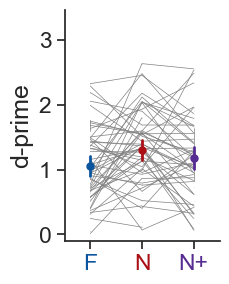

In [77]:
metric = 'mean_dprime_engaged'
stats = behavior_stats_sdk.copy()

ppf.plot_behavior_metric_by_experience(stats, metric, title='', ylabel='d-prime', ylims=[-0.1, 3.3],
                                      best_image=False, show_mice=True, plot_stats=True,
                                      stripplot=False, show_ns=False,
                                      save_dir=save_dir, folder='behavior_metrics', ax=None)

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3968: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(data=data, x='experience_level', y=metric, order=experience_levels,
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3977: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


saving_stats


<Axes: ylabel='Hit rate'>

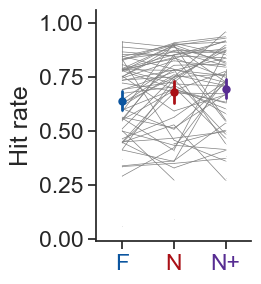

In [78]:
metric = 'mean_hit_rate_engaged'

stats = behavior_stats_sdk.copy()

ppf.plot_behavior_metric_by_experience(stats, metric, title='', ylabel='Hit rate', stripplot=False,
                                        ylims=[-0.01, 1.01], show_mice=True, plot_stats=True, show_ns=False,
                                        save_dir=save_dir, folder='behavior_metrics', ax=None)

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3968: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(data=data, x='experience_level', y=metric, order=experience_levels,
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3977: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


saving_stats


<Axes: ylabel='Response latency (s)'>

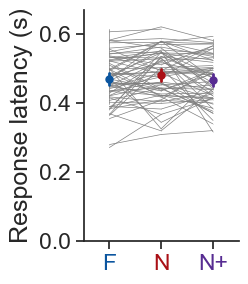

In [79]:
metric = 'response_latency_mean'
stats = behavior_stats_stim.copy()

ppf.plot_behavior_metric_by_experience(stats, metric, title='', ylabel='Response latency (s)', 
                                    ylims=None, show_mice=True, plot_stats=True, stripplot=False, show_ns=False,
                                      save_dir=save_dir, folder='behavior_metrics', ax=None)

In [ ]:
#### Response rate across conditions

In [304]:
platform_behavior_stats

,trial_type,response_probability,behavior_session_id,fraction_engaged,dprime_non_change,dprime_could_change,ophys_session_id,ophys_container_id,mouse_id,indicator,...,stimulus_type,exp_level,engagement,behavior_stage,stimulus_experience_level,date,n_relative_to_first_novel,first_novel,second_novel_active,last_familiar_active
0,change,0.708333,794968300,0.947061,2.164678,0.945272,7.949184e+08,412036,412036,GCaMP6f,...,images,familiar_images,NaN,familiar_images_ophys,familiar_images,20181213,-1.0,False,False,True
1,non_change,0.053030,794968300,0.947061,2.164678,0.945272,7.949184e+08,412036,412036,GCaMP6f,...,images,familiar_images,NaN,familiar_images_ophys,familiar_images,20181213,-1.0,False,False,True
2,could_change,0.345776,794968300,0.947061,2.164678,0.945272,7.949184e+08,412036,412036,GCaMP6f,...,images,familiar_images,NaN,familiar_images_ophys,familiar_images,20181213,-1.0,False,False,True
3,omission,0.352941,794968300,0.947061,2.164678,0.945272,7.949184e+08,412036,412036,GCaMP6f,...,images,familiar_images,NaN,familiar_images_ophys,familiar_images,20181213,-1.0,False,False,True
4,post-omission,0.546218,794968300,0.947061,2.164678,0.945272,7.949184e+08,412036,412036,GCaMP6f,...,images,familiar_images,NaN,familiar_images_ophys,familiar_images,20181213,-1.0,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,change,0.739496,1085690095,0.992506,1.892119,0.947822,1.085675e+09,549976,549976,GCaMP6f,...,images,novel >1_images,NaN,novel >1_images_ophys,novel >1_images,20210222,2.0,False,True,False
996,non_change,0.105590,1085690095,0.992506,1.892119,0.947822,1.085675e+09,549976,549976,GCaMP6f,...,images,novel >1_images,NaN,novel >1_images_ophys,novel >1_images,20210222,2.0,False,True,False
997,could_change,0.379791,1085690095,0.992506,1.892119,0.947822,1.085675e+09,549976,549976,GCaMP6f,...,images,novel >1_images,NaN,novel >1_images_ophys,novel >1_images,20210222,2.0,False,True,False
998,omission,0.257669,1085690095,0.992506,1.892119,0.947822,1.085675e+09,549976,549976,GCaMP6f,...,images,novel >1_images,NaN,novel >1_images_ophys,novel >1_images,20210222,2.0,False,True,False


/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_89513/1418156338.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(trial_types, rotation=45)


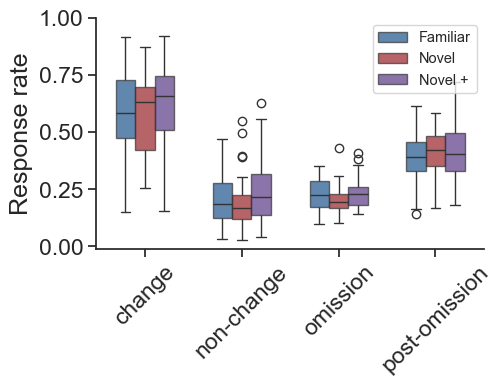

In [309]:
data = platform_behavior_stats.copy()
data = data[data.fraction_engaged>0.7]
data = data[data.trial_type.isin(['change', 'could_change', 'omission', 'post-omission'])]
data['trial_type'] = ['non-change' if trial_type == 'could_change' else trial_type for trial_type in data.trial_type.values]

trial_types = data.trial_type.unique()
figsize = (5,3)
fig, ax = plt.subplots(figsize=figsize)
ax = sns.boxplot(data=data, x='trial_type', y='response_probability', hue='experience_level',
                   order=trial_types, palette=utils.get_experience_level_colors(), width=0.6, boxprops=dict(alpha=0.7), ax=ax)
# ax = sns.swarmplot(data=data, x='trial_type', y='response_probability', 
#                    order=trial_types, color='gray', s=2, ax=ax)
ax.set_ylabel('Response rate')
ax.set_xticklabels(trial_types, rotation=45)
ax.set_xlabel('')
ax.set_ylim(-0.01, 1)
ax.legend(loc='upper right', fontsize='xx-small')

### Event aligned behavior

#### Load dataframes for running, pupil, and licks, for both changes & omissions

In [80]:
#### Multi-session dataframes for behavior variables

epoch_duration_mins = None

# Running speed
running_speed_mdf_changes = loading.get_behavior_multi_session_df('running_speed', 'changes', platform_experiments, epoch_duration_mins=epoch_duration_mins)
running_speed_mdf_images = loading.get_behavior_multi_session_df('running_speed', 'images', platform_experiments, epoch_duration_mins=epoch_duration_mins)
running_speed_mdf_omissions = loading.get_behavior_multi_session_df('running_speed', 'omissions', platform_experiments, epoch_duration_mins=epoch_duration_mins)

# Pupil width
pupil_mdf_changes = loading.get_behavior_multi_session_df('pupil_width', 'changes', platform_experiments, epoch_duration_mins=epoch_duration_mins)
pupil_mdf_images = loading.get_behavior_multi_session_df('pupil_width', 'images', platform_experiments, epoch_duration_mins=epoch_duration_mins)
pupil_mdf_omissions = loading.get_behavior_multi_session_df('pupil_width', 'omissions', platform_experiments, epoch_duration_mins=epoch_duration_mins)

# Lick rate
lick_rate_mdf_changes = loading.get_behavior_multi_session_df('lick_rate', 'changes', platform_experiments, epoch_duration_mins=epoch_duration_mins)
lick_rate_mdf_images = loading.get_behavior_multi_session_df('lick_rate', 'images', platform_experiments, epoch_duration_mins=epoch_duration_mins)
lick_rate_mdf_omissions = loading.get_behavior_multi_session_df('lick_rate', 'omissions', platform_experiments, epoch_duration_mins=epoch_duration_mins)

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_running_speed_all_is_change_platform_experiment_table.pkl
loading multi_session_df from saved file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_running_speed_all_is_change_platform_experiment_table.pkl
there are 1880 experiments in the full multi_session_df


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


removing 1 problematic experiments
there are 402 experiments in the multi_session_df after limiting to platform experiments
there are 402 experiments after filtering for inclusion criteria -  platform_experiment_table


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

...

removing 1 problematic experiments
there are 402 experiments in the multi_session_df after limiting to platform experiments
there are 402 experiments after filtering for inclusion criteria -  platform_experiment_table


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_lick_rate_all_omitted_platform_experiment_table.pkl
loading multi_session_df from saved file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_lick_rate_all_omitted_platform_experiment_table.pkl
there are 1602 experiments in the full multi_session_df


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


removing 1 problematic experiments
there are 402 experiments in the multi_session_df after limiting to platform experiments
there are 402 experiments after filtering for inclusion criteria -  platform_experiment_table


In [81]:
print(len(pupil_mdf_omissions.behavior_session_id.unique()))
print(len(pupil_mdf_omissions.mouse_id.unique()))


161
63


In [82]:
print(len(pupil_mdf_changes.behavior_session_id.unique()))
print(len(pupil_mdf_changes.mouse_id.unique()))


161
63


In [83]:
print(len(running_speed_mdf_omissions.behavior_session_id.unique()))
print(len(running_speed_mdf_omissions.mouse_id.unique()))


156
61


In [84]:
print(len(running_speed_mdf_changes.behavior_session_id.unique()))
print(len(running_speed_mdf_changes.mouse_id.unique()))


202
66


In [85]:
print(len(lick_rate_mdf_omissions.behavior_session_id.unique()))
print(len(lick_rate_mdf_omissions.mouse_id.unique()))


202
66


#### Combined figure - running & pupil

table includes 66 mice


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1920: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


table includes 61 mice


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1920: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


table includes 63 mice


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1920: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


table includes 63 mice


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1920: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


Text(0, 0.5, '')

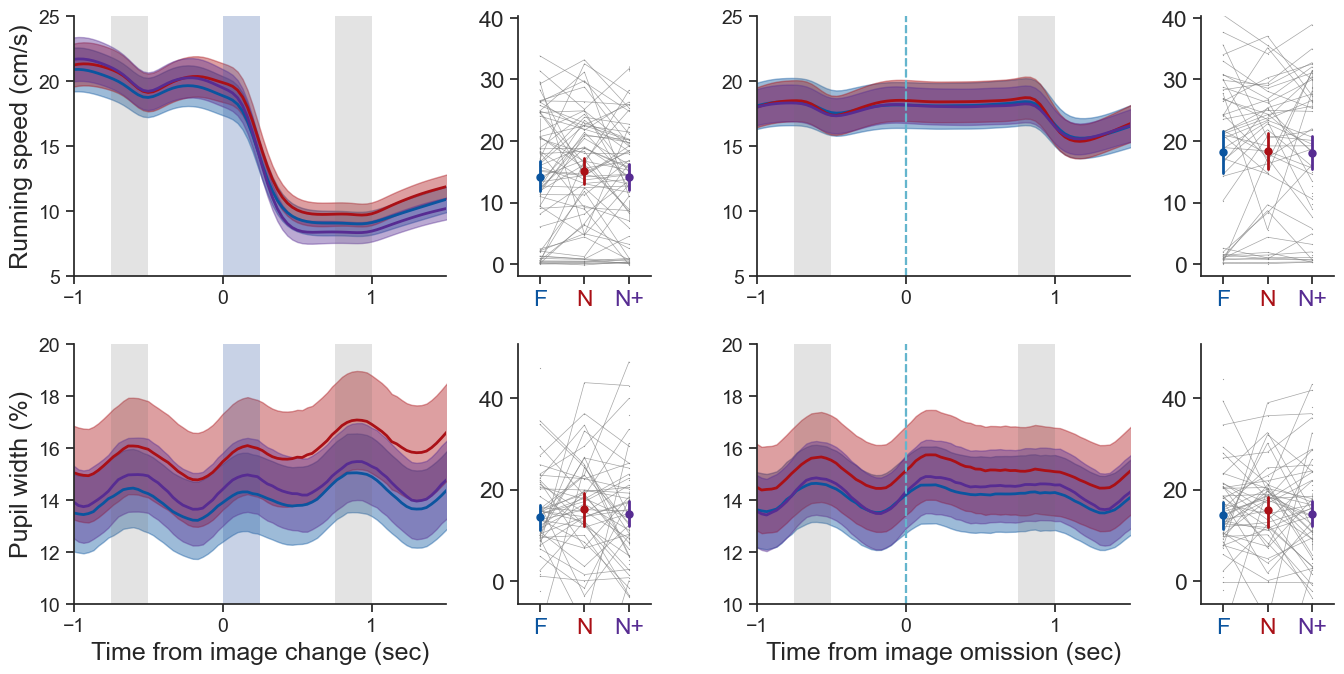

In [86]:
axes_column = 'expts'
hue_column = 'experience_level'
xlim_seconds = [-1, 1.5]
interval_sec = 1

figsize = [2 * 11, 2 * 8.5]
fig = plt.figure(figsize=figsize)


#### Running 

#### Changes

df = running_speed_mdf_changes.copy()
df['expts'] = 'all'

ylims = (-2, 35)
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0, 0.22], yspan=[0, 0.2], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_population_averages_for_condition(df, 'running_speed', 'changes', hue_column, 
                                                ylabel='Running speed (cm/s)', linewidth=2, ylims=(5, 25),
                                                xlim_seconds=xlim_seconds, interval_sec=interval_sec,
                                                xlabel='Time from image change (sec)', ax=ax)
ax.set_xlabel('')

ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[.26, 0.34], yspan=[0, 0.2], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'changes', 'running_speed', 
                                            ylabel='', ylims=ylims, show_mice=True,
                                            pointplot=True, stripplot=False, horiz=False, title='',ax=ax)
ax.set_ylabel('')



#### Omissions 

df = running_speed_mdf_omissions.copy()
df['expts'] = 'all'
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[.4, 0.62], yspan=[0, 0.2], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_population_averages_for_condition(df, 'running_speed', 'omissions', hue_column, ylims=(5, 25),
                                                ylabel='Running speed (cm/s)', xlim_seconds=xlim_seconds, linewidth=2, 
                                                interval_sec=interval_sec, xlabel='Time from image omission (sec)', ax=ax)
ax.set_xlabel('')
ax.set_ylabel('')

ylims = (-2, 35)
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[.66, 0.74], yspan=[0, 0.2], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'omissions', 'running_speed', 
                                            ylabel='', ylims=ylims, show_mice=True,
                                            pointplot=True, stripplot=False, horiz=False, title='', ax=ax)
ax.set_ylabel('')


#### Pupil 

#### Changes


df = pupil_mdf_changes.copy()
# Set baseline to 0 instead of 1
df['expts'] = 'all'
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0.0, 0.22], yspan=[0.25, 0.45], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_population_averages_for_condition(df, 'pupil_width', 'changes', hue_column, ylims=(10, 20),
                                                ylabel='Pupil width (%)', xlim_seconds=xlim_seconds, linewidth=2, 
                                                interval_sec=interval_sec, xlabel='Time from image change (sec)', ax=ax)

ylims = (-0.1, 0.5)
ylims = (-5, 45)
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0.26, 0.34], yspan=[0.25, 0.45], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'changes', 'pupil_width', 
                                            ylabel='', ylims=ylims, show_mice=True,
                                            pointplot=True, stripplot=False, horiz=False, title='', ax=ax)
ax.set_ylabel('')


#### Omissions

df = pupil_mdf_omissions.copy()
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[.4, 0.62], yspan=[0.25, 0.45], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_population_averages_for_condition(df, 'pupil_width', 'omissions', hue_column, ylims=(10, 20),
                                                ylabel='Pupil width (%)', xlim_seconds=xlim_seconds, linewidth=2, 
                                                interval_sec=interval_sec, xlabel='Time from image omission (sec)', ax=ax)
ax.set_ylabel('')

ylims = (-0.1, 0.5)
ylims = (-5, 45)
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[.66, 0.74], yspan=[0.25, 0.45], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'omissions', 'pupil_width', 
                                            ylabel='', ylims=ylims, show_mice=True,
                                            pointplot=True, stripplot=False, horiz=False, title='', ax=ax)
ax.set_ylabel('')




#### Combined plot including lick rate

table includes 66 mice


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1920: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


table includes 61 mice


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1920: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


table includes 63 mice


...

table includes 66 mice


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1920: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


table includes 66 mice


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1920: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


Text(0, 0.5, '')

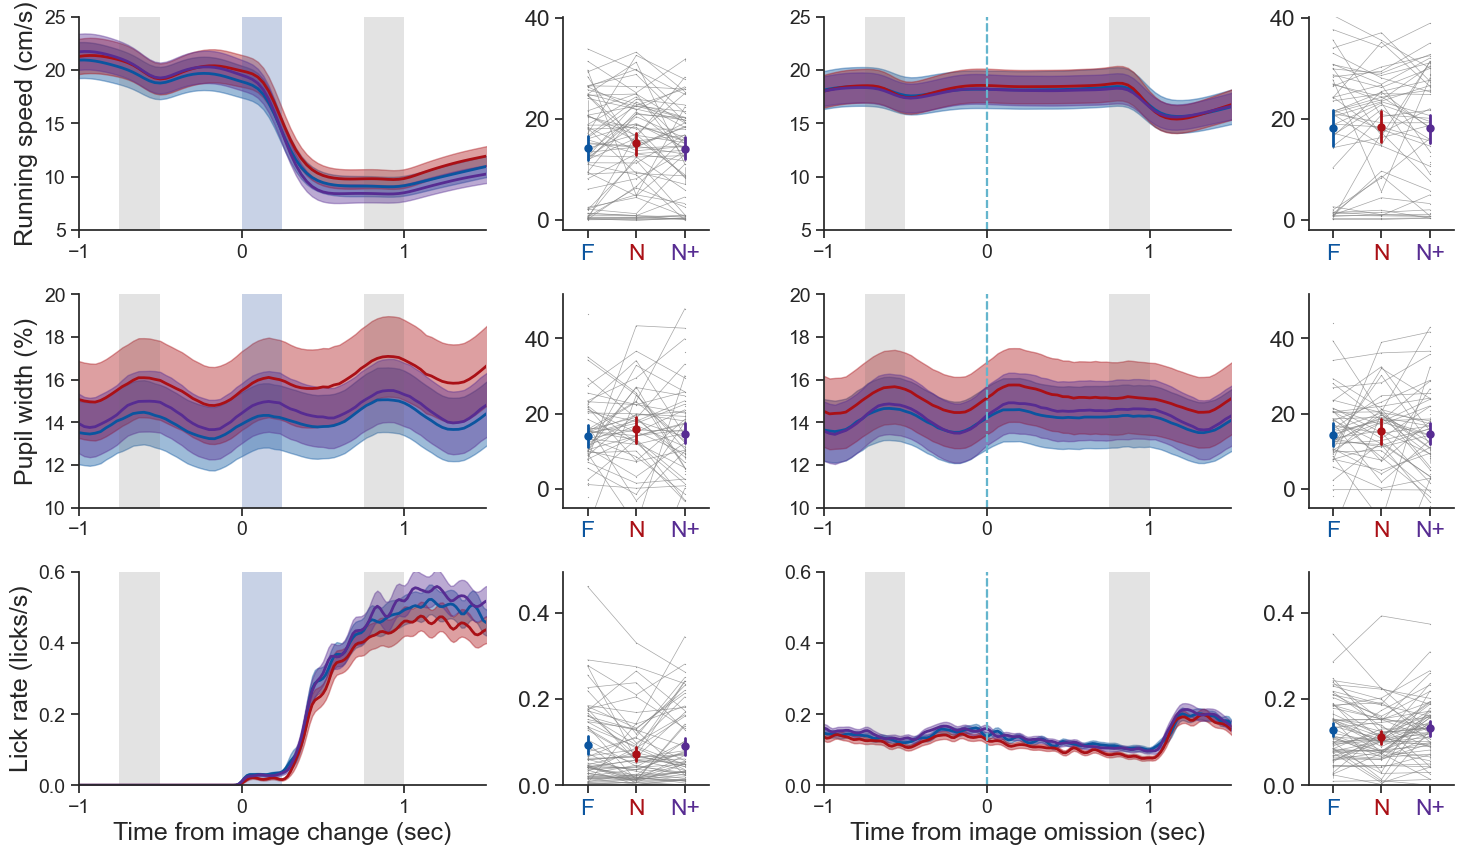

In [301]:
axes_column = 'expts'
hue_column = 'experience_level'
xlim_seconds = [-1, 1.5]
interval_sec = 1

figsize = [2 * 12, 2 * 10]
fig = plt.figure(figsize=figsize)


#### Running 

#### Changes

df = running_speed_mdf_changes.copy()
df['expts'] = 'all'

ylims = (-2, 35)
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0, 0.22], yspan=[0, 0.14], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_population_averages_for_condition(df, 'running_speed', 'changes', hue_column, 
                                                ylabel='Running speed (cm/s)', linewidth=2, ylims=(5, 25),
                                                xlim_seconds=xlim_seconds, interval_sec=interval_sec,
                                                xlabel='Time from image change (sec)', ax=ax)
ax.set_xlabel('')

ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[.26, 0.34], yspan=[0, 0.14], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'changes', 'running_speed', 
                                            ylabel='', ylims=ylims, show_mice=True,
                                            pointplot=True, stripplot=False, horiz=False, title='',ax=ax)
ax.set_ylabel('')



#### Omissions 

df = running_speed_mdf_omissions.copy()
df['expts'] = 'all'
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[.4, 0.62], yspan=[0, 0.14], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_population_averages_for_condition(df, 'running_speed', 'omissions', hue_column, ylims=(5, 25),
                                                ylabel='Running speed (cm/s)', xlim_seconds=xlim_seconds, linewidth=2, 
                                                interval_sec=interval_sec, xlabel='Time from image omission (sec)', ax=ax)
ax.set_xlabel('')
ax.set_ylabel('')

ylims = (-2, 35)
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[.66, 0.74], yspan=[0, 0.14], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'omissions', 'running_speed', 
                                            ylabel='', ylims=ylims, show_mice=True,
                                            pointplot=True, stripplot=False, horiz=False, title='', ax=ax)
ax.set_ylabel('')


#### Pupil 

#### Changes


df = pupil_mdf_changes.copy()
df['expts'] = 'all'
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0.0, 0.22], yspan=[0.18, 0.32], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_population_averages_for_condition(df, 'pupil_width', 'changes', hue_column, ylims=(10, 20),
                                                ylabel='Pupil width (%)', xlim_seconds=xlim_seconds, linewidth=2, 
                                                interval_sec=interval_sec, xlabel='Time from image change (sec)', ax=ax)
ax.set_xlabel('')

ylims = (-5, 45)
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0.26, 0.34], yspan=[0.18, 0.32], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'changes', 'pupil_width', 
                                            ylabel='', ylims=ylims, show_mice=True,
                                            pointplot=True, stripplot=False, horiz=False, title='', ax=ax)
ax.set_ylabel('')


#### Omissions

df = pupil_mdf_omissions.copy()
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[.4, 0.62], yspan=[0.18, 0.32], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_population_averages_for_condition(df, 'pupil_width', 'omissions', hue_column, ylims=(10, 20),
                                                ylabel='Pupil width (%)', xlim_seconds=xlim_seconds, linewidth=2, 
                                                interval_sec=interval_sec, xlabel='Time from image omission (sec)', ax=ax)
ax.set_ylabel('')
ax.set_xlabel('')

ylims = (-5, 45)
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[.66, 0.74], yspan=[0.18, 0.32], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'omissions', 'pupil_width', 
                                            ylabel='', ylims=ylims, show_mice=True,
                                            pointplot=True, stripplot=False, horiz=False, title='', ax=ax)
ax.set_ylabel('')


#### Lick rate

#### Changes

df = lick_rate_mdf_changes.copy()
df['mean_trace'] = [mean_trace*10 for mean_trace in df.mean_trace.values]
df['mean_response'] = [mean_response*10 for mean_response in df.mean_response.values]

df['expts'] = 'all'
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0.0, 0.22], yspan=[0.36, 0.50], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_population_averages_for_condition(df, 'lick_rate', 'changes', hue_column, 
                                                ylabel='Lick rate (licks/s)', linewidth=2, ylims=(0, 0.6),
                                                xlim_seconds=xlim_seconds, interval_sec=interval_sec,
                                                xlabel='Time from image change (sec)', ax=ax)

ylims_lick = None
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0.26, 0.34], yspan=[0.36, 0.50], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'changes', 'lick_rate', 
                                            ylabel='', ylims=(0, 0.43), show_mice=True,
                                            pointplot=True, stripplot=False, horiz=False, title='', ax=ax)
ax.set_ylabel('')


#### Omissions

df = lick_rate_mdf_omissions.copy()
df['mean_trace'] = [mean_trace*10 for mean_trace in df.mean_trace.values]
df['mean_response'] = [mean_response*10 for mean_response in df.mean_response.values]

df['expts'] = 'all'
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[.4, 0.62], yspan=[0.36, 0.50], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_population_averages_for_condition(df, 'lick_rate', 'omissions', hue_column, ylims=(0, 0.6),
                                                ylabel='Lick rate (licks/s)', xlim_seconds=xlim_seconds, linewidth=2, 
                                                interval_sec=interval_sec, xlabel='Time from image omission (sec)', ax=ax)
ax.set_ylabel('')

ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[.66, 0.74], yspan=[0.36, 0.50], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'omissions', 'lick_rate', 
                                            ylabel='', ylims=(0, 0.43), show_mice=True,
                                            pointplot=True, stripplot=False, horiz=False, title='', ax=ax)
ax.set_ylabel('')

### Within session changes in behavior

In [88]:
#### Multi-session dataframes for behavior variables

epoch_duration_mins = 5

# Running speed
running_speed_mdf_changes_epochs = loading.get_behavior_multi_session_df('running_speed', 'changes', platform_experiments, epoch_duration_mins=epoch_duration_mins)
running_speed_mdf_images_epochs = loading.get_behavior_multi_session_df('running_speed', 'images', platform_experiments, epoch_duration_mins=epoch_duration_mins)
running_speed_mdf_omissions_epochs = loading.get_behavior_multi_session_df('running_speed', 'omissions', platform_experiments, epoch_duration_mins=epoch_duration_mins)

# Pupil width
pupil_mdf_changes_epochs = loading.get_behavior_multi_session_df('pupil_width', 'changes', platform_experiments, epoch_duration_mins=epoch_duration_mins)
pupil_mdf_images_epochs = loading.get_behavior_multi_session_df('pupil_width', 'images', platform_experiments, epoch_duration_mins=epoch_duration_mins)
pupil_mdf_omissions_epochs = loading.get_behavior_multi_session_df('pupil_width', 'omissions', platform_experiments, epoch_duration_mins=epoch_duration_mins)

# Lick rate
lick_rate_mdf_changes_epochs = loading.get_behavior_multi_session_df('lick_rate', 'changes', platform_experiments, epoch_duration_mins=epoch_duration_mins)
lick_rate_mdf_images_epochs = loading.get_behavior_multi_session_df('lick_rate', 'images', platform_experiments, epoch_duration_mins=epoch_duration_mins)
lick_rate_mdf_omissions_epochs = loading.get_behavior_multi_session_df('lick_rate', 'omissions', platform_experiments, epoch_duration_mins=epoch_duration_mins)

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_running_speed_all_is_change_epoch_epoch_dur_5_platform_experiment_table.pkl
loading multi_session_df from saved file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_running_speed_all_is_change_epoch_epoch_dur_5_platform_experiment_table.pkl
there are 1880 experiments in the full multi_session_df


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

removing 1 problematic experiments
there are 402 experiments in the multi_session_df after limiting to platform experiments
there are 402 experiments after filtering for inclusion criteria -  platform_experiment_table


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

...

removing 1 problematic experiments
there are 402 experiments in the multi_session_df after limiting to platform experiments
there are 402 experiments after filtering for inclusion criteria -  platform_experiment_table


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_lick_rate_all_omitted_epoch_epoch_dur_5_platform_experiment_table.pkl
loading multi_session_df from saved file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_lick_rate_all_omitted_epoch_epoch_dur_5_platform_experiment_table.pkl
there are 1602 experiments in the full multi_session_df


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


removing 1 problematic experiments
there are 402 experiments in the multi_session_df after limiting to platform experiments
there are 402 experiments after filtering for inclusion criteria -  platform_experiment_table


#### Across 5 minute epochs 

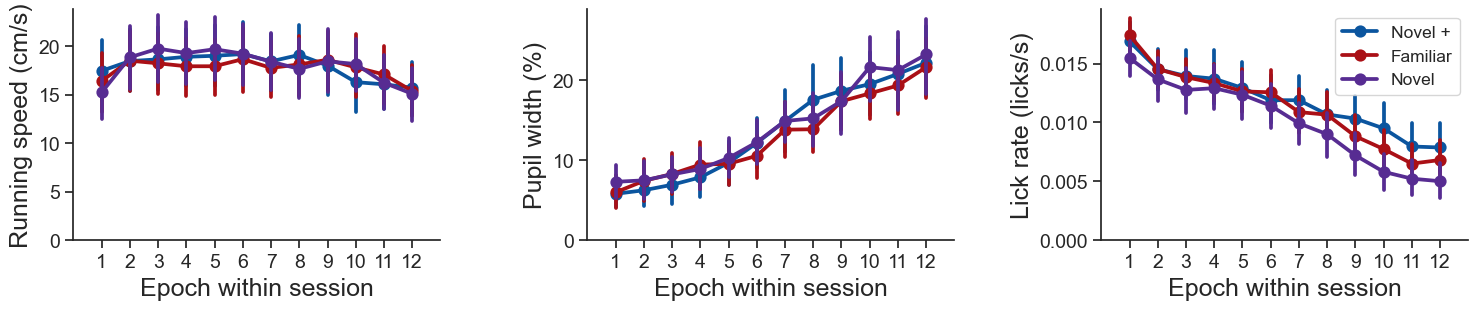

In [89]:
figsize = (18, 3)
fig, ax = plt.subplots(1, 3, figsize=figsize)

i = 0
ax[i] = ppf.plot_mean_response_by_epoch_all_cell_types(running_speed_mdf_images_epochs, metric='mean_response', horizontal=True, ymin=0, 
                                ylabel='Running speed (cm/s)', title='', legend=False, estimator=np.mean, max_epoch=11, ax=ax[i])

i = 1
ax[i] = ppf.plot_mean_response_by_epoch_all_cell_types(pupil_mdf_images_epochs, metric='mean_response', horizontal=True, ymin=0, 
                                ylabel='Pupil width (%)', title='', legend=False, estimator=np.mean, max_epoch=11, ax=ax[i])

i = 2
ax[i] = ppf.plot_mean_response_by_epoch_all_cell_types(lick_rate_mdf_images_epochs, metric='mean_response', horizontal=True, ymin=0, 
                                ylabel='Lick rate (licks/s)', title='', legend=True, estimator=np.mean, max_epoch=11, ax=ax[i])


#### Per cre line

array([<Axes: title={'center': 'Excitatory'}, xlabel='Epoch within session', ylabel='Lick rate (licks/s)'>,
       <Axes: title={'center': 'Sst Inhibitory'}, xlabel='Epoch within session'>,
       <Axes: title={'center': 'Vip Inhibitory'}, xlabel='Epoch within session'>],
      dtype=object)

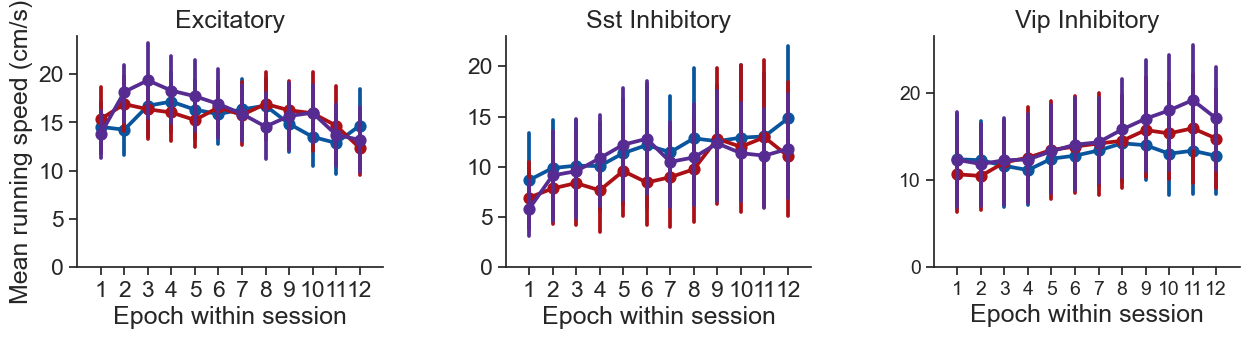

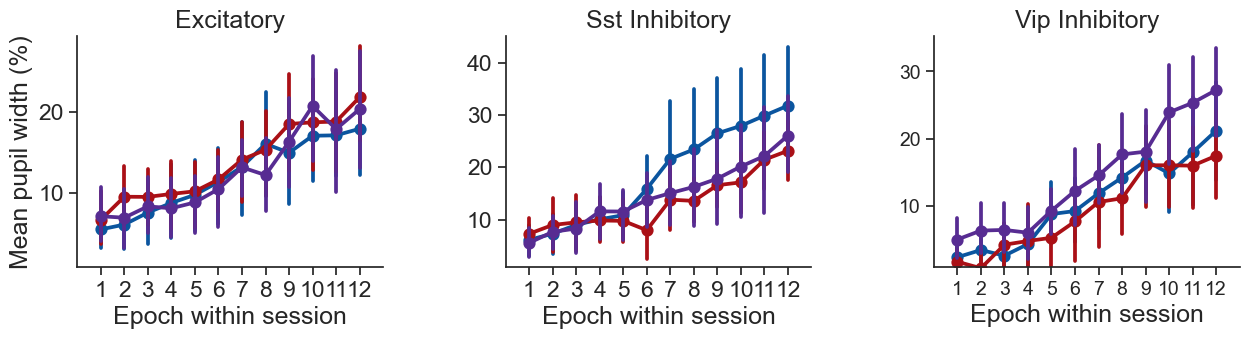

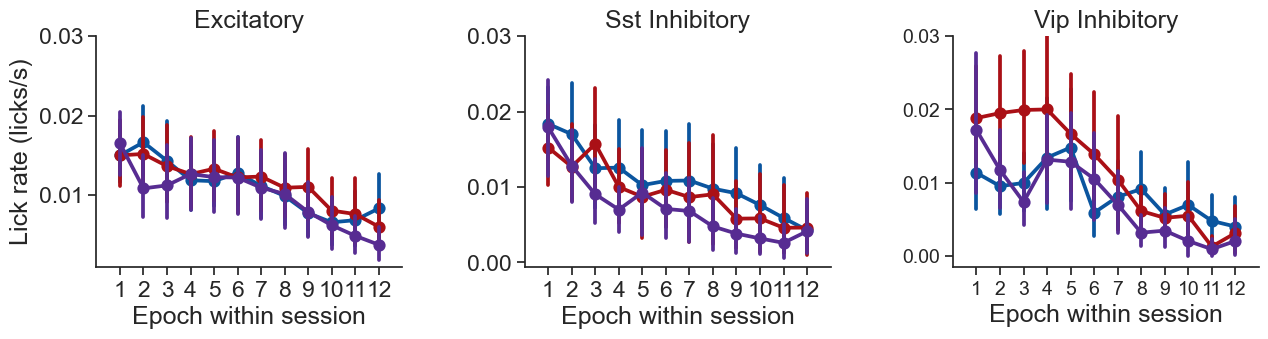

In [90]:
suffix = '_running_speed_images_within_session'
ppf.plot_mean_response_by_epoch(running_speed_mdf_changes_epochs, metric='mean_response', horizontal=True, ymin=0,
                               ylabel='Mean running speed (cm/s)', estimator=np.mean,
                               save_dir=save_dir, folder='within_session_behavior', max_epoch=11, ax=None)

# Pupil width by epoch
suffix = '_pupil_width_images_within_session'
ppf.plot_mean_response_by_epoch(pupil_mdf_changes_epochs, metric='mean_response', horizontal=True, ymin=0.9,
                               ylabel='Mean pupil width (%)', estimator=np.mean,
                               save_dir=save_dir, folder='within_session_behavior', max_epoch=11, ax=None)

# Lick rate by epoch
suffix = '_lick_rate_images_within_session'
ppf.plot_mean_response_by_epoch(lick_rate_mdf_changes_epochs, metric='mean_response', horizontal=True, ymin=None,
                               ylabel='Lick rate (licks/s)', estimator=np.mean, ymax=0.03,
                               save_dir=save_dir, folder='within_session_behavior', max_epoch=11, ax=None)

### Across 10 second bins 

In [91]:
# mouse_id = platform_experiments.mouse_id.unique()[0]
file_dir = os.path.join(loading.get_stimulus_behavior_response_dir())
stim_behavior_response_df = pd.DataFrame()
problem_mice = []
for mouse_id in platform_experiments.mouse_id.unique(): 
    filename = str(mouse_id)+'_behavior_across_stimuli_df.csv'
    filepath = os.path.join(file_dir, filename)
    try: 
        df = pd.read_csv(filepath, index_col=0)
        df['mouse_id'] = mouse_id
        stim_behavior_response_df = pd.concat((stim_behavior_response_df, df))
    except:
        problem_mice.append(mouse_id)
print(len(stim_behavior_response_df.mouse_id.unique()))
print(problem_mice)

66
[]


In [151]:
stim_behavior_df = stim_behavior_response_df.merge(platform_experiments.reset_index(), 
                                                            on=['behavior_session_id', 'mouse_id'], how='left')

# Convert to percentage of baseline                                                       
stim_behavior_df['mean_pupil_width'] = stim_behavior_df['mean_pupil_width'] - 1
stim_behavior_df['mean_pupil_width'] = stim_behavior_df['mean_pupil_width'] * 100
# Start epoch at 1 not zero
# stim_behavior_df['epoch'] = stim_behavior_df['epoch'] + 1 # change epoch numbering to start at 1 instead of 0 for easier interpretation in plots

stim_behavior_df.head()

,stimulus_presentations_id,start_time,relative_time,epoch,is_change,omitted,post_omitted,image_name,mean_running_speed,mean_pupil_width,...,layer,area_layer,date,first_novel,n_relative_to_first_novel,last_familiar,last_familiar_active,second_novel,second_novel_active,experience_exposure
0,1,307.176084,0.00000,0,False,False,False,im065,12.685861,6.695455,...,upper,VISp_upper,20181213,False,-1.0,True,True,False,False,Familiar 3
1,2,307.926674,0.75059,0,False,False,False,im065,12.339447,6.398520,...,upper,VISp_upper,20181213,False,-1.0,True,True,False,False,Familiar 3
2,3,308.677274,1.50119,0,False,False,False,im065,26.097918,5.167729,...,upper,VISp_upper,20181213,False,-1.0,True,True,False,False,Familiar 3
3,4,309.427924,2.25184,0,False,False,False,im065,30.444546,2.722607,...,upper,VISp_upper,20181213,False,-1.0,True,True,False,False,Familiar 3
4,5,310.178494,3.00241,0,False,False,False,im065,28.378029,2.916830,...,upper,VISp_upper,20181213,False,-1.0,True,True,False,False,Familiar 3


In [207]:
image_sdf = stim_behavior_df.reset_index()

# Calculate the relative stimulus_presentations_id
image_sdf['stimulus_number'] = image_sdf.groupby(['mouse_id', 'ophys_session_id']).cumcount() + 1

# Check that everything is there
print(len(image_sdf.mouse_id.unique()))


66


<Axes: title={'center': 'Pupil width over first 2 minutes of session'}, xlabel='Time (sec)', ylabel='Pupil width (%)'>

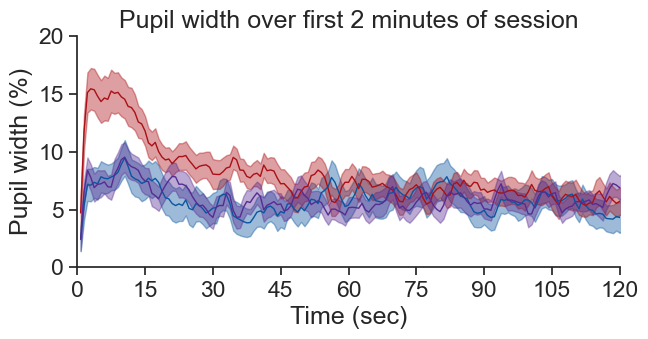

In [298]:
metric = 'mean_pupil_width'
ylabel = 'Pupil width (%)'
time_window_min = 2
ylim = (0, 20)
title = f'Pupil width over first {time_window_min} minutes of session'

ppf.plot_metric_across_stimuli_by_experience_level(image_sdf, metric, time_window_min=time_window_min, 
                                                title=title, ylabel=ylabel, ylim=ylim, 
                                                interval=20, ax=None, save_dir=save_dir, 
                                                folder='within_session_behavior')


<Axes: title={'center': 'Running speed across first 2 minutes of session'}, xlabel='Time (sec)', ylabel='Running speed (cm/s)'>

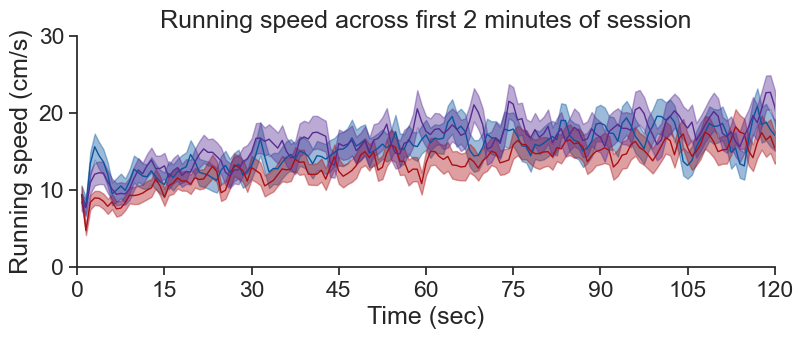

In [284]:
metric = 'mean_running_speed'
ylabel = 'Running speed (cm/s)'
time_window_min = 2
ylim = (0, 30)
title = f'Running speed across first {time_window_min} minutes of session'

ppf.plot_metric_across_stimuli_by_experience_level(image_sdf, metric, time_window_min=time_window_min, 
                                                title=title, ylabel=ylabel, ylim=ylim, 
                                                interval=20, ax=None, save_dir=save_dir, 
                                                folder='within_session_behavior')

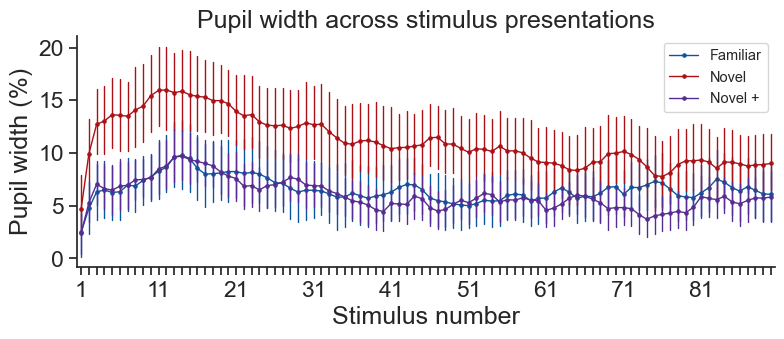

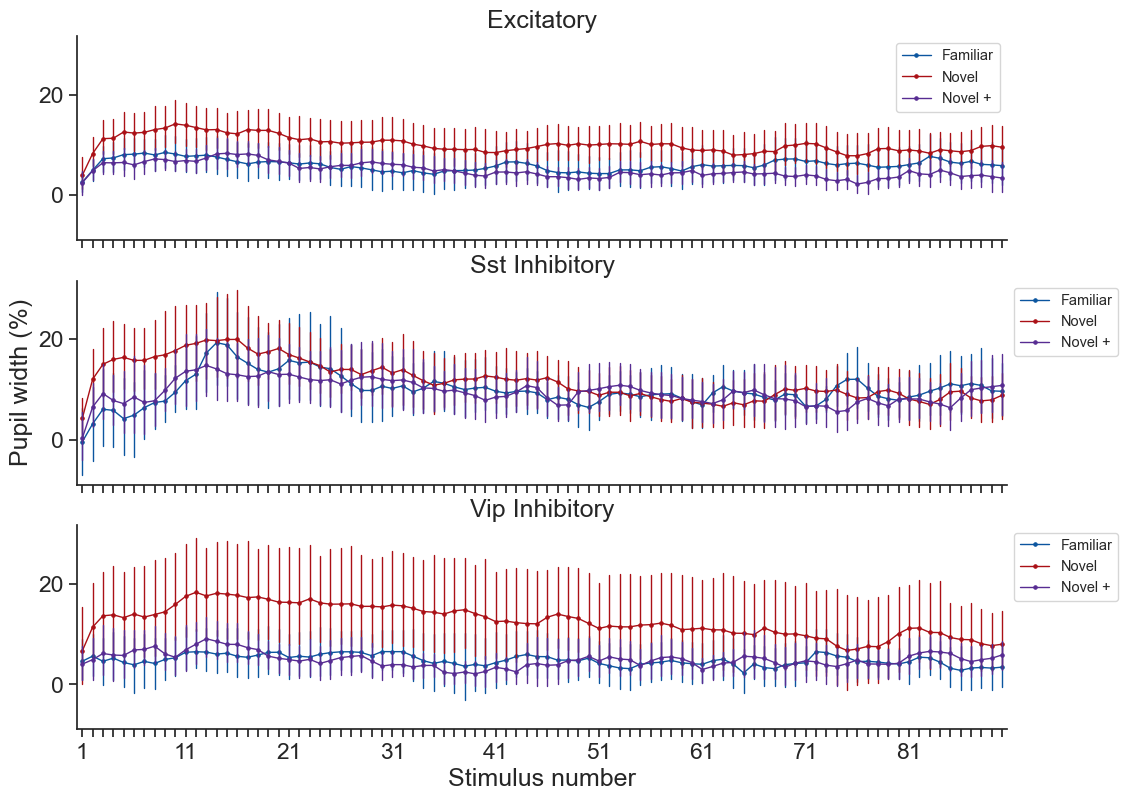

In [ ]:
metric = 'mean_pupil_width'
x = 'stimulus_number'
df = image_sdf[image_sdf.epoch<20]
df = df[df.stimulus_number<=(60*2)*0.75]
title = 'Pupil width across stimulus presentations'
ylabel = 'Pupil width (%)'

ppf.plot_metric_over_repeats(df, metric, x, title, ylabel=ylabel, save_dir=None, folder='within_session_behavior')
# ppf.plot_metric_over_repeats_for_cell_types(df, metric, x, ylabel=ylabel, save_dir=None, folder='within_session_behavior')


#### Licking behavior over time in session

<Axes: title={'center': 'Lick latency across first 2 minutes of session'}, xlabel='Time (sec)', ylabel='Lick latency (s)'>

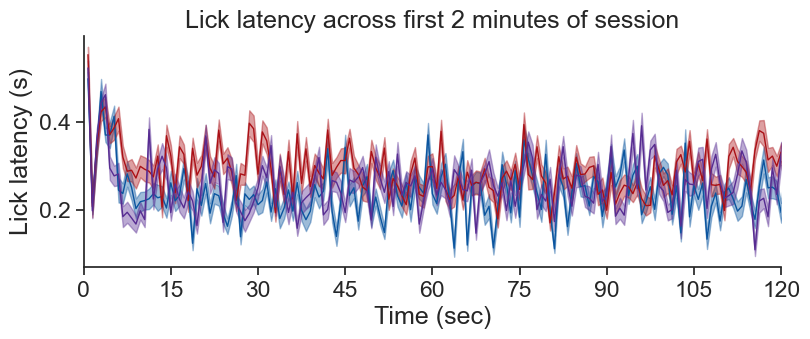

In [287]:
metric = 'lick_latency'
ylabel = 'Lick latency (s)'
time_window_min = 2
ylim = None
title = f'Lick latency across first {time_window_min} minutes of session'

ppf.plot_metric_across_stimuli_by_experience_level(image_sdf, metric, time_window_min=time_window_min, 
                                                title=title, ylabel=ylabel, ylim=ylim, 
                                                interval=20, ax=None, save_dir=save_dir, 
                                                folder='within_session_behavior')

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1741: RuntimeWarning: invalid value encountered in subtract
  np.subtract(arr, avg, out=arr, casting='unsafe', where=where)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1741: RuntimeWarning: invalid value encountered in subtract
  np.subtract(arr, avg, out=arr, casting='unsafe', where=where)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1741: RuntimeWarning: invalid value encountered in subtract
  np.subtract(arr, avg, out=arr, casting='unsafe', where=where)


<Axes: title={'center': 'Reward rate over time in session'}, xlabel='Time (min)', ylabel='Rewards per minute'>

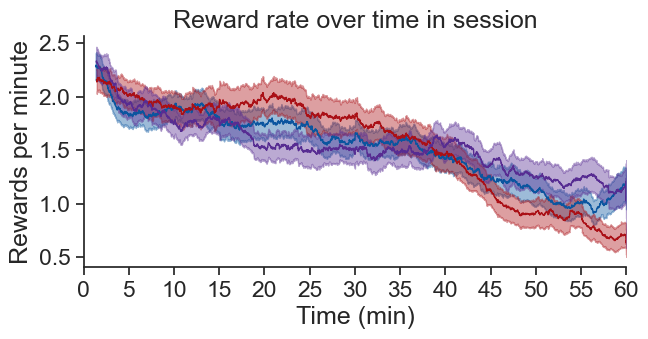

In [299]:
metric = 'reward_rate'
ylabel = 'Rewards per minute'
time_window_min = 60
ylim = None
title = f'Reward rate over time in session'

ppf.plot_metric_across_stimuli_by_experience_level(image_sdf, metric, time_window_min=time_window_min, 
                                                title=title, ylabel=ylabel, ylim=ylim, show_x_in_minutes=True,
                                                interval=400, ax=None, save_dir=save_dir, 
                                                folder='within_session_behavior')

In [302]:
## Plot all together

In [ ]:
mouse_id = 425496

# Get datasets for each experience level
familiar_experiment_id = platform_experiments[(platform_experiments.mouse_id == mouse_id) &
                                             (platform_experiments.experience_level == 'Familiar')].index.values[0]
familiar_dataset = loading.get_ophys_dataset(familiar_experiment_id)

novel_experiment_id = platform_experiments[(platform_experiments.experience_level == 'Novel') &
                                         (platform_experiments.mouse_id == mouse_id)].index.values[0]
novel_dataset = loading.get_ophys_dataset(novel_experiment_id)

novel_plus_experiment_id = platform_experiments[(platform_experiments.experience_level == 'Novel +') &
                                              (platform_experiments.mouse_id == mouse_id)].index.values[0]
novel_plus_dataset = loading.get_ophys_dataset(novel_plus_experiment_id)

# Plot lick rasters for F/N/N+
colors = utils.get_experience_level_colors()
figsize = (12, 4)
fig, ax = plt.subplots(1, 3, figsize=figsize, sharey=True)

trials = familiar_dataset.trials.copy()
trials = trials[trials.go == True]
trials = trials[:100]
ax[0] = ppf.plot_lick_raster_for_trials(trials, title='Familiar', save_dir=None, suffix='_familiar', ax=ax[0])
ax[0].set_title('Familiar', color=colors[0])
ax[0].set_xlabel('')

trials = novel_dataset.trials.copy()
trials = trials[trials.go == True]
trials = trials[:100]
ax[1] = ppf.plot_lick_raster_for_trials(trials, title='Novel', save_dir=None, suffix='_novel', ax=ax[1])
ax[1].set_title('Novel', color=colors[1])
ax[1].set_ylabel('')

trials = novel_plus_dataset.trials.copy()
trials = trials[trials.go == True]
trials = trials[:100]
ax[2] = ppf.plot_lick_raster_for_trials(trials, title='Novel +', save_dir=None, suffix='_novel_plus', ax=ax[2])
ax[2].set_title('Novel +', color=colors[2])
ax[2].set_ylabel('')
ax[2].set_xlabel('')

plt.subplots_adjust(wspace=0.3)
plt.suptitle(mouse_id, x=0.6, y=1.03, fontsize=16)
utils.save_figure(fig, figsize, save_dir, 'lick_rasters', str(mouse_id) + '_F_N_N+_example_fig')

In [ ]:
axes_column = 'expts'
hue_column = 'experience_level'
xlim_seconds = [-1, 1.5]
interval_sec = 1

figsize = [2 * 12, 2 * 10]
fig = plt.figure(figsize=figsize)


#### Running 

#### Changes

df = running_speed_mdf_changes.copy()
df['expts'] = 'all'

ylims = (-2, 35)
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0, 0.22], yspan=[0, 0.14], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_population_averages_for_condition(df, 'running_speed', 'changes', hue_column, 
                                                ylabel='Running speed (cm/s)', linewidth=2, ylims=(5, 25),
                                                xlim_seconds=xlim_seconds, interval_sec=interval_sec,
                                                xlabel='Time from image change (sec)', ax=ax)
ax.set_xlabel('')

ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[.26, 0.34], yspan=[0, 0.14], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'changes', 'running_speed', 
                                            ylabel='', ylims=ylims, show_mice=True,
                                            pointplot=True, stripplot=False, horiz=False, title='',ax=ax)
ax.set_ylabel('')



#### Omissions 

df = running_speed_mdf_omissions.copy()
df['expts'] = 'all'
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[.4, 0.62], yspan=[0, 0.14], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_population_averages_for_condition(df, 'running_speed', 'omissions', hue_column, ylims=(5, 25),
                                                ylabel='Running speed (cm/s)', xlim_seconds=xlim_seconds, linewidth=2, 
                                                interval_sec=interval_sec, xlabel='Time from image omission (sec)', ax=ax)
ax.set_xlabel('')
ax.set_ylabel('')

ylims = (-2, 35)
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[.66, 0.74], yspan=[0, 0.14], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'omissions', 'running_speed', 
                                            ylabel='', ylims=ylims, show_mice=True,
                                            pointplot=True, stripplot=False, horiz=False, title='', ax=ax)
ax.set_ylabel('')


#### Pupil 

#### Changes


df = pupil_mdf_changes.copy()
df['expts'] = 'all'
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0.0, 0.22], yspan=[0.18, 0.32], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_population_averages_for_condition(df, 'pupil_width', 'changes', hue_column, ylims=(10, 20),
                                                ylabel='Pupil width (%)', xlim_seconds=xlim_seconds, linewidth=2, 
                                                interval_sec=interval_sec, xlabel='Time from image change (sec)', ax=ax)
ax.set_xlabel('')

ylims = (-5, 45)
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0.26, 0.34], yspan=[0.18, 0.32], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'changes', 'pupil_width', 
                                            ylabel='', ylims=ylims, show_mice=True,
                                            pointplot=True, stripplot=False, horiz=False, title='', ax=ax)
ax.set_ylabel('')


#### Omissions

df = pupil_mdf_omissions.copy()
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[.4, 0.62], yspan=[0.18, 0.32], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_population_averages_for_condition(df, 'pupil_width', 'omissions', hue_column, ylims=(10, 20),
                                                ylabel='Pupil width (%)', xlim_seconds=xlim_seconds, linewidth=2, 
                                                interval_sec=interval_sec, xlabel='Time from image omission (sec)', ax=ax)
ax.set_ylabel('')
ax.set_xlabel('')

ylims = (-5, 45)
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[.66, 0.74], yspan=[0.18, 0.32], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'omissions', 'pupil_width', 
                                            ylabel='', ylims=ylims, show_mice=True,
                                            pointplot=True, stripplot=False, horiz=False, title='', ax=ax)
ax.set_ylabel('')


#### Lick rate

#### Changes

df = lick_rate_mdf_changes.copy()
df['mean_trace'] = [mean_trace*10 for mean_trace in df.mean_trace.values]
df['mean_response'] = [mean_response*10 for mean_response in df.mean_response.values]

df['expts'] = 'all'
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0.0, 0.22], yspan=[0.36, 0.50], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_population_averages_for_condition(df, 'lick_rate', 'changes', hue_column, 
                                                ylabel='Lick rate (licks/s)', linewidth=2, ylims=(0, 0.6),
                                                xlim_seconds=xlim_seconds, interval_sec=interval_sec,
                                                xlabel='Time from image change (sec)', ax=ax)

ylims_lick = None
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0.26, 0.34], yspan=[0.36, 0.50], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'changes', 'lick_rate', 
                                            ylabel='', ylims=(0, 0.43), show_mice=True,
                                            pointplot=True, stripplot=False, horiz=False, title='', ax=ax)
ax.set_ylabel('')


#### Omissions

df = lick_rate_mdf_omissions.copy()
df['mean_trace'] = [mean_trace*10 for mean_trace in df.mean_trace.values]
df['mean_response'] = [mean_response*10 for mean_response in df.mean_response.values]

df['expts'] = 'all'
ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[.4, 0.62], yspan=[0.36, 0.50], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_population_averages_for_condition(df, 'lick_rate', 'omissions', hue_column, ylims=(0, 0.6),
                                                ylabel='Lick rate (licks/s)', xlim_seconds=xlim_seconds, linewidth=2, 
                                                interval_sec=interval_sec, xlabel='Time from image omission (sec)', ax=ax)
ax.set_ylabel('')

ax = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[.66, 0.74], yspan=[0.36, 0.50], wspace=None, hspace=None,
                    sharex=False, sharey=False, width_ratios=None, height_ratios=None)
ax = ppf.plot_metric_distribution_by_experience_no_cell_type(df, 'mean_response', 'omissions', 'lick_rate', 
                                            ylabel='', ylims=(0, 0.43), show_mice=True,
                                            pointplot=True, stripplot=False, horiz=False, title='', ax=ax)
ax.set_ylabel('')

In [ ]:
metric = 'mean_pupil_width'
ylabel = 'Pupil width (%)'
time_window_min = 2
ylim = (0, 20)
title = f'Pupil width over first {time_window_min} minutes of session'

ppf.plot_metric_across_stimuli_by_experience_level(image_sdf, metric, time_window_min=time_window_min, 
                                                title=title, ylabel=ylabel, ylim=ylim, 
                                                interval=20, ax=None, save_dir=save_dir, 
                                                folder='within_session_behavior')


In [ ]:
metric = 'reward_rate'
ylabel = 'Rewards per minute'
time_window_min = 60
ylim = None
title = f'Reward rate over time in session'

ppf.plot_metric_across_stimuli_by_experience_level(image_sdf, metric, time_window_min=time_window_min, 
                                                title=title, ylabel=ylabel, ylim=ylim, show_x_in_minutes=True,
                                                interval=400, ax=None, save_dir=save_dir, 
                                                folder='within_session_behavior')